#### Problem Statement

Email Service Providers (such as SendGrid, Mailchimp) need to maintain and protect the trust of the email channel; can the subject and body of an outbound message be scanned and used to detect and block spam before delivery?

An email service provider's traffic is inherently "open" in that customers (or potentially customers of their customers) send mail that is potentially spam.  A spam filter trained narrowly on a focused data set or singular writing style risks two failure modes on emails that don't resemble the training set - missing spam that doesn't resemble the training examples, or misclassifying legitmate email as spam.

This project asks whether the subject and body text of an outbound email can be used to reliably screen for spam against this business context.

**Goals**:
- Build a binary spam classifier from email subject/body text
- Evaluate for production readiness, weighing quality against inference cost

**Challenges**:
- The open-world nature of email service provider traffic means the model will always see senders and styles absent from training
- False positives are costlier than false negatives

**Potential benefits**:
- Protects channel trust (and ability to operate) without overly blocking legitmate customer email


In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Training, tuning and load test validation

In [ ]:
# This notebook requires that the training and tuning scripts have already been executed and that the 
# artifacts are available in artifacts/
def check(path: str, script: str) -> None:
    if not Path(path).exists():
        print(f"Artifact {path} not found; please execute {script}")    

check("artifacts/classic_wider_ngrams.metrics.json", "./scripts/train-classic-batch.sh")
check("artifacts/classic_tuned.metrics.json", "./scripts/tune-classic-baseline.sh")

check("artifacts/dnn_baseline.metrics.json", "./scripts/train-dnn-batch.sh")
check("artifacts/dnn_tuned_arch.summary.json", "./scripts/tune-dnn.sh")

In [ ]:
# This notebook requires that inference load tests have been executed and artifacts are available 
# in loadtest-results/
def check_loadtest(tag_prefix: str, instructions: list[str]) -> None:
      if not any(Path("loadtest-results").glob(f"{tag_prefix}*/summary.csv")):
          print(f"Load test results loadtest-results/{tag_prefix}*/summary.csv not found; please execute:")
          for instruction in instructions:
              print(f"  {instruction}")
          
check_loadtest("classic", [
    "./scripts/run-service-for-loadtest.sh",
    "./scripts/run-loadtest.sh configs/loadtest-baseline.json <tag>",
])  
check_loadtest("dnn", [
    "./scripts/run-service-for-loadtest.sh artifacts dnn_tuned_from_search.manifest.json",
    "./scripts/run-loadtest.sh configs/loadtest-baseline.json <tag>",
])


#### Inference Load Test - Results Analysis

TODO - describe load test

In [ ]:
RUN_TAGS = {    
    "classic (1 worker": "classic-single-worker",
    "classic (4 workers)": "classic",
    "dnn tuned (4 workers)": "dnn-tuned",
}   

def load_summary(tag_prefix : str) -> pd.DataFrame:
    match = sorted(Path("loadtest-results").glob(f"{tag_prefix}*/summary.csv"))[-1]
    return pd.read_csv(match)

frames = []
for label, tag_prefix in RUN_TAGS.items():
    df = load_summary(tag_prefix)
    df["run"] = label
    frames.append(df)

df_loadtest = pd.concat(frames, ignore_index=True)


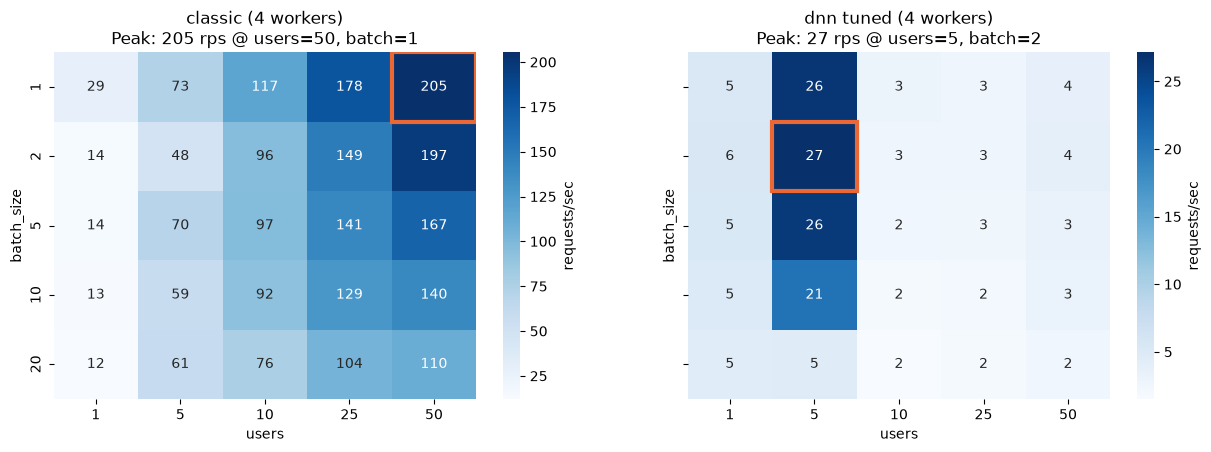

In [23]:
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, (label, tag_prefix) in zip(axes, RUN_TAGS.items()):
    df = load_summary(tag_prefix)
    
    pivot = df.pivot(index="batch_size", columns="users", values="rps")
    sns.heatmap(
        pivot, ax=ax, cmap="Blues", annot=True, fmt=".0f",
        cbar_kws={"label": "requests/sec"}
    )

    peak_batch, peak_users = pivot.stack().idxmax()
    peak_rps = pivot.loc[peak_batch, peak_users]
    row_pos = list(pivot.index).index(peak_batch)
    col_pos = list(pivot.columns).index(peak_users)
    ax.add_patch(patches.Rectangle(
        (col_pos, row_pos), 1, 1, fill=False, edgecolor="#eb6834", lw=3,
    ))

    ax.set_title(f"{label}\nPeak: {peak_rps:.0f} rps @ users={peak_users}, batch={peak_batch}")
